In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
import os
warnings.filterwarnings('ignore')

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import lightgbm as lgb
import xgboost as xgb

In [41]:
df = pd.read_csv('/content/monthly_features-2.csv', encoding='latin-1')

In [42]:
df.head()

,Year,Month,Total_Sales,Avg_Sales,Order_count,Customer_count,Lag_1,Lag_2,Lag_3,Rolling_3,Mom_1,Mom_3,Growth_rate,Quarter,Month_Sin,Month_Cos,Is_Holiday_Month,Is_Quarter_END
0,2015,4,27906.8550,214.668115,63,61,55205.7970,4519.8920,14205.707,24643.798667,-27298.9420,13701.1480,-49.449412,2,8.660254e-01,-0.500000,0,0
1,2015,5,23644.3030,195.407463,68,66,27906.8550,55205.7970,4519.892,29210.848000,-4262.5520,19124.4110,-15.274211,2,5.000000e-01,-0.866025,0,0
2,2015,6,34322.9356,262.007142,64,61,23644.3030,27906.8550,55205.797,35585.651667,10678.6326,-20882.8614,45.163660,2,1.224647e-16,-1.000000,0,1
3,2015,7,33781.5430,237.898190,64,64,34322.9356,23644.3030,27906.855,28624.697867,-541.3926,5874.6880,-1.577349,3,-5.000000e-01,-0.866025,0,0
4,2015,8,27117.5365,185.736551,70,68,33781.5430,34322.9356,23644.303,30582.927200,-6664.0065,3473.2335,-19.726768,3,-8.660254e-01,-0.500000,0,0


In [43]:
with open('/content/selected_features-2.json') as f:
    selected_features = json.load(f)

In [44]:
print("Data Shape : ",df.shape)
print(f"Selected Features : {len(selected_features)}")

Data Shape :  (45, 18)
Selected Features : 13


In [45]:
selected_features

['Year',
 'Month',
 'Quarter',
 'Month_Sin',
 'Month_Cos',
 'Is_Holiday_Month',
 'Is_Quarter_END',
 'Lag_1',
 'Lag_2',
 'Lag_3',
 'Rolling_3',
 'Order_count',
 'Customer_count']

In [46]:
selected_features = ['Year', 'Month', 'Quarter', 'Month_Sin', 'Month_Cos', 'Is_Holiday_Month', 'Is_Quarter_END', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_3']

In [47]:
len(selected_features)

11

In [48]:
data = df[selected_features + ['Total_Sales']].dropna()
X = data[selected_features]
y = data['Total_Sales']

print("X Shape : ",X.shape)
print("y shape : ",y.shape)

X Shape :  (45, 11)
y shape :  (45,)


###Train and Test Split

In [49]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f'Train shape : {len(X_train)}')
print(f'Test shape : {len(X_test)}')
print("Train Period:")
print(f" From : {df['Year'].iloc[0]}-{df['Month'].iloc[0]:02d}")
print(f" To : {df['Year'].iloc[split_idx-1]}-{df['Month'].iloc[split_idx-1]:02d}")
print("Test Period : ")
print(f" From : {df['Year'].iloc[split_idx]}-{df['Month'].iloc[split_idx]:02d}")
print(f" To : {df['Year'].iloc[-1]}-{df['Month'].iloc[-1]:02d}")

Train shape : 36
Test shape : 9
Train Period:
 From : 2015-04
 To : 2018-03
Test Period : 
 From : 2018-04
 To : 2018-12


In [50]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Unnamed Model"):
  """Train the model and evaluate it."""

  model.fit(X_train, y_train)

  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)

  metrics = {
        'Model': name,
        'Train_MAPE': round(
            mean_absolute_percentage_error(
                y_train, y_pred_train
            ) * 100, 2
        ),
        'Test_MAPE': round(
            mean_absolute_percentage_error(
                y_test, y_pred_test
            ) * 100, 2
        ),
        'Test_MAE': round(
            mean_absolute_error(
                y_test, y_pred_test
            ), 2
        ),
        'Test_RMSE': round(
            np.sqrt(mean_squared_error(
                y_test, y_pred_test
            )), 2
        ),
        'Test_R2': round(
            r2_score(y_test, y_pred_test),
            4
        )
    }

  return metrics, y_pred_test, model

###Model Training

In [51]:
models = {
    'Linear Regression' : LinearRegression(),

    'Random Forest' : RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'Gredient Boosting': GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ),

    'XGBoost': xgb.XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbosity=0
    ),

    'LightGBM': lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbose=-1
    )
}

all_models = []
all_predictions = {}
trained_models = {}

for name, model in models.items():
  print(f"Trainintg {name}...")

  metrics, y_pred, trained = evaluate_model(
      model, X_train, X_test, y_train, y_test, name
  )

  all_models.append(metrics)
  all_predictions[name] = y_pred
  trained_models[name] = trained

  print(f" Train MAPE : {metrics['Train_MAPE']}%")
  print(f" Test MAPE : {metrics['Test_MAPE']}%")
  print(f" Test R2 : {metrics['Test_R2']}")

Trainintg Linear Regression...
 Train MAPE : 18.58%
 Test MAPE : 16.4%
 Test R2 : 0.477
Trainintg Random Forest...
 Train MAPE : 11.94%
 Test MAPE : 18.9%
 Test R2 : 0.449
Trainintg Gredient Boosting...
 Train MAPE : 0.0%
 Test MAPE : 18.11%
 Test R2 : 0.5865
Trainintg XGBoost...
 Train MAPE : 0.02%
 Test MAPE : 20.74%
 Test R2 : 0.4211
Trainintg LightGBM...
 Train MAPE : 53.64%
 Test MAPE : 29.55%
 Test R2 : -0.7998


###Model Comparison

In [52]:
results_df = pd.DataFrame(all_models)
results_df = results_df.sort_values('Test_MAPE')

print("All Models Performance : ")
print(results_df.to_string(index=False))

All Models Performance : 
            Model  Train_MAPE  Test_MAPE  Test_MAE  Test_RMSE  Test_R2
Linear Regression       18.58      16.40  12783.62   18225.21   0.4770
Gredient Boosting        0.00      18.11  13253.48   16206.05   0.5865
    Random Forest       11.94      18.90  14027.20   18707.47   0.4490
          XGBoost        0.02      20.74  15214.34   19175.40   0.4211
         LightGBM       53.64      29.55  24502.84   33809.04  -0.7998


In [53]:
best_model_name = results_df.iloc[0]['Model']
best_mape = results_df.iloc[0]['Test_MAPE']

print(f"Best Model : {best_model_name}")
print(f"Test MAPE : {best_mape}%")
print(f"Accuracy : {100-best_mape}%")



Best Model : Linear Regression
Test MAPE : 16.4%
Accuracy : 83.6%


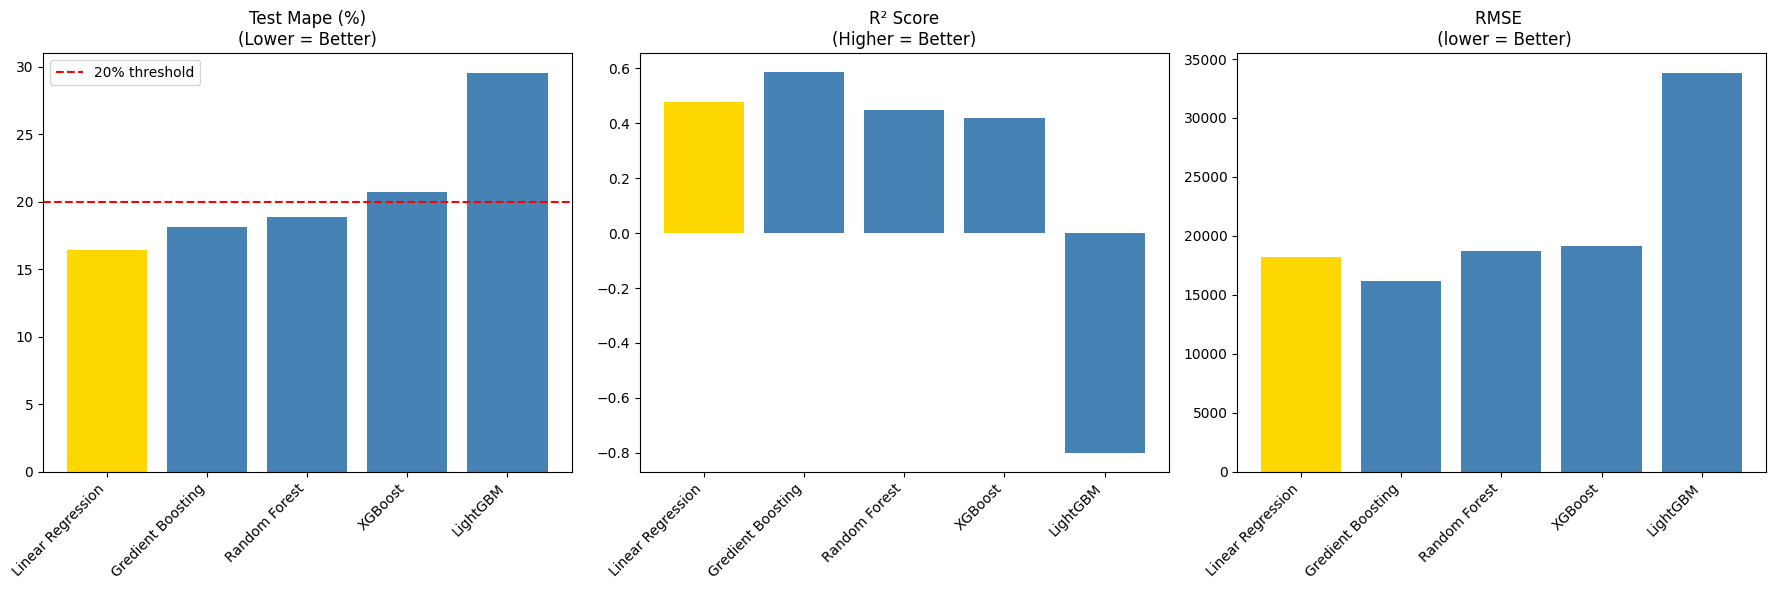

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['gold' if m == best_model_name else 'steelblue' for m in results_df['Model']]

axes[0].bar(
    results_df['Model'],
    results_df['Test_MAPE'],
    color=colors
)
axes[0].set_title('Test Mape (%)\n(Lower = Better)', fontsize=12)
axes[0].set_xticklabels(results_df['Model'], rotation=45, ha='right')
axes[0].axhline(y=20, color='red', linestyle='--', label='20% threshold')
axes[0].legend()


axes[1].bar(
    results_df['Model'],
    results_df['Test_R2'],
    color=colors
)
axes[1].set_title('R² Score\n(Higher = Better)', fontsize=12)
axes[1].set_xticklabels(results_df['Model'], rotation=45, ha='right')

axes[2].bar(
    results_df['Model'],
    results_df['Test_RMSE'],
    color=colors
)
axes[2].set_title('RMSE \n (lower = Better)', fontsize=12)
axes[2].set_xticklabels(results_df['Model'], rotation=45, ha='right')

plt.tight_layout()

os.makedirs('notebooks', exist_ok=True)
plt.savefig('notebooks/12_model_comparison.png',dpi=150)
plt.show()

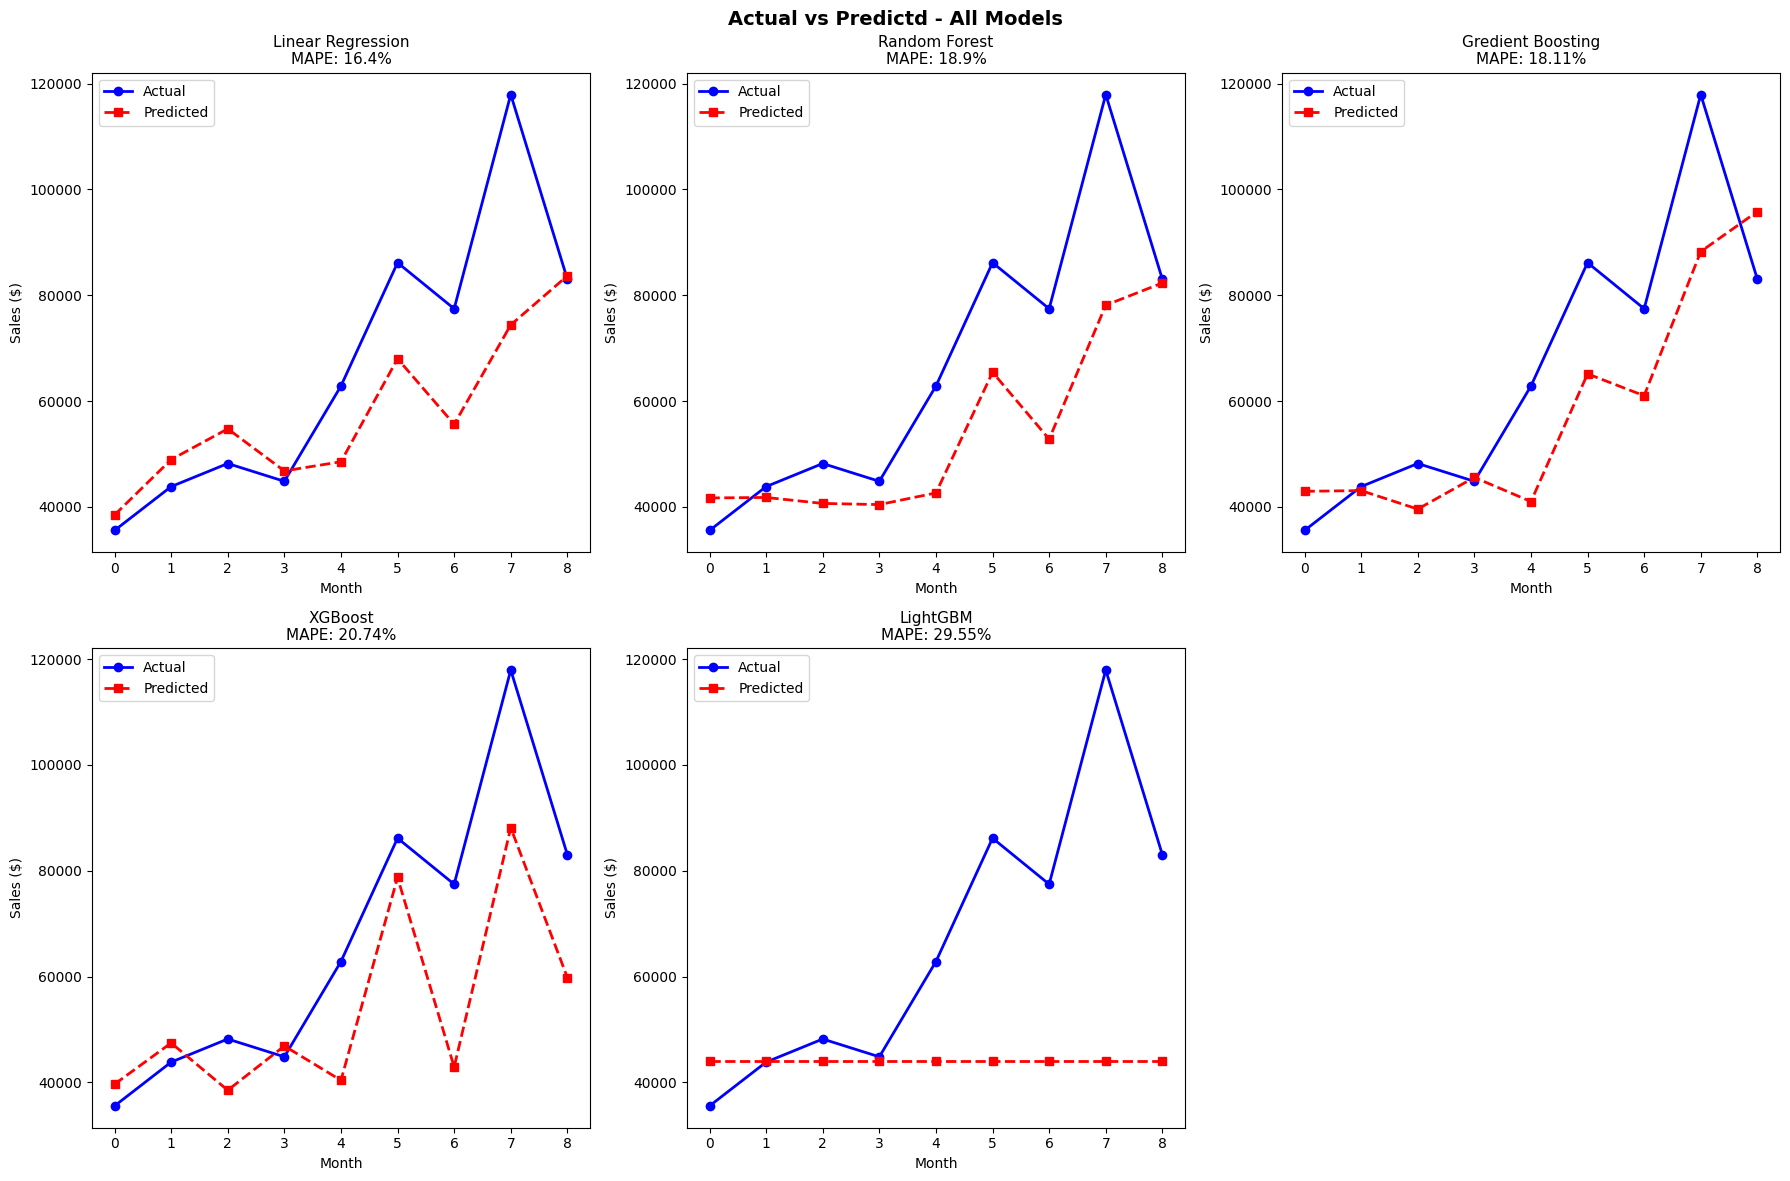

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (name, y_pred) in enumerate(all_predictions.items()):
  axes[idx].plot(
      range(len(y_test)),
      y_test.values,
      label='Actual',
      color='blue',
      linewidth=2,
      marker='o'
  )
  axes[idx].plot(
      range(len(y_pred)),
      y_pred,
      label='Predicted',
      color='red',
      linewidth=2,
      linestyle='--',
      marker='s'
  )
  mape = results_df[results_df['Model'] == name]['Test_MAPE'].values[0]
  axes[idx].set_title(f'{name}\nMAPE: {mape}%',fontsize=11)
  axes[idx].legend()
  axes[idx].set_xlabel('Month')
  axes[idx].set_ylabel('Sales ($)')

if len(all_predictions) < 6:
  for i in range(len(all_predictions), 6):
    axes[i].set_visible(False)
plt.suptitle('Actual vs Predictd - All Models', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.savefig('notebooks/13_actual_vs_predicted.png',dpi=150)
plt.show()

###Cross - validation

In [56]:
tscv = TimeSeriesSplit(n_splits=5)

cv_results = {}

for name, model in trained_models.items():
  cv_scores = cross_val_score(
      model, X, y, cv=tscv, scoring='neg_mean_absolute_percentage_error',
      n_jobs=-1
  )
  cv_mape = -cv_scores.mean() * 100
  cv_std = cv_scores.std() * 100

  cv_results[name] = {
      'CV_MAPE': round(cv_mape, 2),
      'CV_STD': round(cv_std, 2)
  }
  print(f"{name}: "f"MAPE={cv_mape:.2f}% "f"(±{cv_std:.2f}%)")

best_model = trained_models[best_model_name]




Linear Regression: MAPE=55.21% (±48.49%)
Random Forest: MAPE=28.98% (±9.57%)
Gredient Boosting: MAPE=29.23% (±6.70%)
XGBoost: MAPE=28.96% (±4.19%)
LightGBM: MAPE=42.78% (±16.75%)


In [57]:
import pickle
import os
os.makedirs('models', exist_ok=True)
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print(f"\n✅ Best model saved: {best_model_name}")


✅ Best model saved: Linear Regression
